## Features of LeNet-5

- **Hierarchical Feature Extraction:** Each convolutional layer consists of three main components: **convolution** (for spatial feature extraction), **average pooling** (for subsampling and dimensionality reduction), and **nonlinear activation functions** (specifically, the `tanh` function).
- **Sparse Connectivity:** Layers are not fully connected, which reduces the number of parameters and computational complexity, making the network more efficient.
- **Receptive Fields:** Convolutional layers use local receptive fields to capture spatial hierarchies and patterns in the input images.
- **Activation Function:** The `tanh` activation function is used throughout the network, introducing nonlinearity and enabling the model to learn complex representations.
- **Subsampling:** Average pooling layers are used for downsampling, which helps in making the representations more robust to small translations and distortions.
- **Fully Connected Classifier:** The final layers are fully connected (Multi-Layer Perceptron), serving as the classifier to output the probability distribution over classes.
- **Parameter Sharing:** Convolutional layers share weights, further reducing the number of parameters and improving generalization.
- **Designed for Image Recognition:** LeNet-5 was originally developed for handwritten digit recognition (e.g., MNIST dataset), but its architecture inspired many modern convolutional neural networks.

In [14]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

### Preprocessing and normalizing the data

In [15]:
rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows, cols, 1)

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

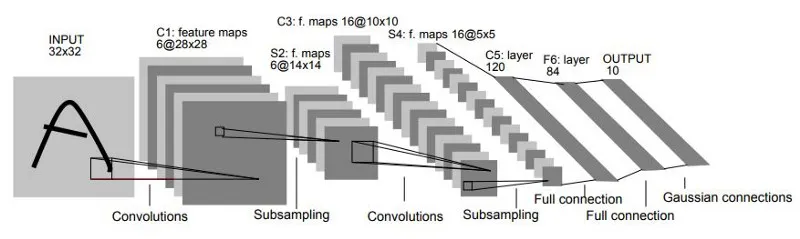

### Defining LeNet-5 Model 

In [16]:

def build_lenet(input_shape):
    # Define Sequential Model
    model = tf.keras.Sequential()

    # C1 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=6, strides=(1, 1),
              kernel_size=(5, 5), activation='tanh', input_shape=input_shape))

    # S2 SubSampling Layer (AvgPooling Layer)
    model.add(tf.keras.layers.AveragePooling2D(
        pool_size=(2, 2), strides=(2, 2)))

    # C3 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=6, strides=(
        1, 1), kernel_size=(5, 5), activation='tanh'))

    # S4 SubSampling Layer (AvgPooling Layer)
    model.add(tf.keras.layers.AveragePooling2D(
        pool_size=(2, 2), strides=(2, 2)))

    # C5 Fully Connected Layer
    model.add(tf.keras.layers.Dense(units=120, activation='tanh'))

    # Flatten the output so that we can connect it with the fully connected layers by converting it into a 1D Array
    model.add(tf.keras.layers.Flatten())

    # FC6 Fully Connected Layers
    model.add(tf.keras.layers.Dense(units=84, activation='tanh'))

    # Output Layer
    model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

    # Compile the Model
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.SGD(learning_rate=0.1, weight_decay=0.0), metrics=['accuracy'])

    return model

### Model Architecture

In [17]:
lenet = build_lenet(input_shape)
lenet.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 24, 24, 6)         156       
                                                                 
 average_pooling2d_2 (Averag  (None, 12, 12, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 6)           906       
                                                                 
 average_pooling2d_3 (Averag  (None, 4, 4, 6)          0         
 ePooling2D)                                                     
                                                                 
 dense_3 (Dense)             (None, 4, 4, 120)         840       
                                                                 
 flatten_1 (Flatten)         (None, 1920)             

### Train the Model on the train image data

In [18]:
# We will be allowing 10 iterations to happen
epochs = 10
history = lenet.fit(x_train, y_train, epochs=epochs, batch_size=128,
                    verbose=1, use_multiprocessing=True, workers=4)

Epoch 1/10
469/469 [==============================] - 8s 16ms/step - loss: 0.4284 - accuracy: 0.8817
Epoch 2/10
469/469 [==============================] - 7s 16ms/step - loss: 0.1874 - accuracy: 0.9453
Epoch 3/10
469/469 [==============================] - 7s 15ms/step - loss: 0.1309 - accuracy: 0.9618
Epoch 4/10
469/469 [==============================] - 7s 16ms/step - loss: 0.1010 - accuracy: 0.9704
Epoch 5/10
469/469 [==============================] - 8s 16ms/step - loss: 0.0830 - accuracy: 0.9758
Epoch 6/10
469/469 [==============================] - 8s 16ms/step - loss: 0.0723 - accuracy: 0.9785
Epoch 7/10
469/469 [==============================] - 7s 16ms/step - loss: 0.0642 - accuracy: 0.9810
Epoch 8/10
469/469 [==============================] - 7s 16ms/step - loss: 0.0576 - accuracy: 0.9828
Epoch 9/10
469/469 [==============================] - 8s 16ms/step - loss: 0.0531 - accuracy: 0.9841
Epoch 10/10
469/469 [==============================] - 8s 16ms/step - loss: 0.0494 - accura

### Evalute the Model Accuracy

In [19]:
# Check Accuracy of the Model
loss, acc = lenet.evaluate(x_test, y_test)
print('Accuracy : ', acc)

313/313 [==============================] - 1s 3ms/step - loss: 0.0465 - accuracy: 0.9854
Accuracy :  0.9854000210762024


### Make Predictions

In [20]:
x_train = x_train.reshape(x_train.shape[0], 28, 28)
print('Training Data', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28, 28)
print('Test Data', x_test.shape, y_test.shape)

Training Data (60000, 28, 28) (60000, 10)
Test Data (10000, 28, 28) (10000, 10)


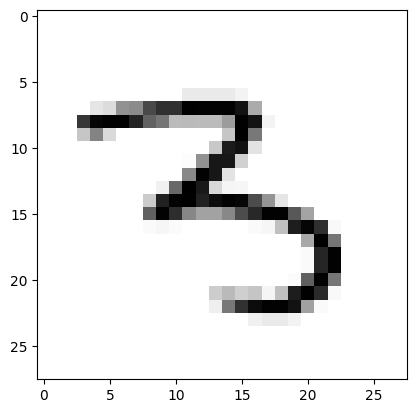

In [21]:
# Plot a sample image
image_index = 1298
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')

In [22]:
# Make Prediction -- .predict() return the probabilities of each class
pred = lenet.predict(x_test[image_index].reshape(1, rows, cols, 1))
# we can use argmax to get the class with highest probability
print(pred.argmax(axis=1))

1/1 [==============================] - 0s 80ms/step
[3]
